🔹 Training model for output bit: Y2
✅ Y2 Accuracy: 1.000
Confusion Matrix:
 [[4 0]
 [0 4]]
Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8

🔹 Training model for output bit: Y1
✅ Y1 Accuracy: 1.000
Confusion Matrix:
 [[4 0]
 [0 4]]
Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8

🔹 Training model for output bit: Y0
✅ Y0 Accuracy: 1.000
Confusion Matrix:
 [[4 0]
 [0 4]]
Report:
               precision    recall  f1-score   

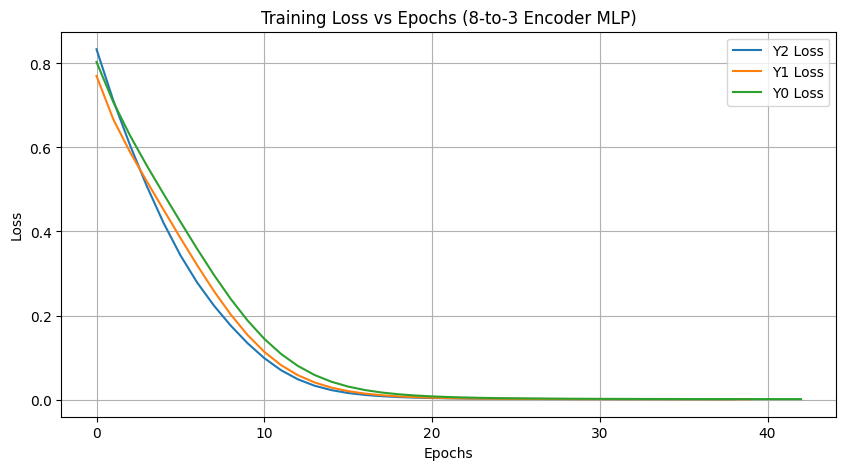

In [1]:
# encoder_8to3_mlp.py
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ======================================================
# 1️⃣ Define dataset for 8-to-3 Encoder
# ======================================================
# Inputs: 8-bit one-hot (only one HIGH at a time)
X = np.eye(8, dtype=int)

# Outputs: 3-bit binary encoding [Y2, Y1, Y0]
y = np.array([
    [0, 0, 0],
    [0, 0, 1],
    [0, 1, 0],
    [0, 1, 1],
    [1, 0, 0],
    [1, 0, 1],
    [1, 1, 0],
    [1, 1, 1]
])

# ======================================================
# 2️⃣ Train three MLP models — one per output bit
# ======================================================
models = {}
loss_curves = {}
for i, bit in enumerate(["Y2", "Y1", "Y0"]):
    print(f"🔹 Training model for output bit: {bit}")

    model = MLPClassifier(
        hidden_layer_sizes=(10,),
        activation="tanh",
        solver="adam",
        learning_rate_init=0.05,
        max_iter=2000,
        random_state=42 + i
    )

    model.fit(X, y[:, i])
    preds = model.predict(X)
    acc = accuracy_score(y[:, i], preds)

    print(f"✅ {bit} Accuracy: {acc:.3f}")
    print("Confusion Matrix:\n", confusion_matrix(y[:, i], preds))
    print("Report:\n", classification_report(y[:, i], preds))

    models[bit] = model
    loss_curves[bit] = model.loss_curve_

# ======================================================
# 3️⃣ Overall verification
# ======================================================
preds = np.column_stack([models["Y2"].predict(X),
                         models["Y1"].predict(X),
                         models["Y0"].predict(X)])

overall_acc = np.mean(np.all(preds == y, axis=1))
print(f"\n🎯 Overall Encoder Accuracy: {overall_acc * 100:.2f}%")
print("\nExpected vs Predicted:")
for i, (inp, exp, prd) in enumerate(zip(X, y, preds)):
    print(f"{inp} -> Expected: {exp} | Predicted: {prd}")

# ======================================================
# 4️⃣ Plot Training Loss for Each Output Bit
# ======================================================
plt.figure(figsize=(10, 5))
for bit, curve in loss_curves.items():
    plt.plot(curve, label=f"{bit} Loss")
plt.title("Training Loss vs Epochs (8-to-3 Encoder MLP)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [3]:
import joblib

# Assuming you just trained each model in a loop
# Example structure:
# for i, bit in enumerate(["Y2", "Y1", "Y0"]):
#     model = MLPClassifier(...)
#     model.fit(X, y[:, i])

for i, bit in enumerate(["Y2", "Y1", "Y0"]):
    filename = f"frontend/models/8to3_Encoder_{bit}_mlp.pkl"
    joblib.dump(models[bit], filename)
    print(f"✅ Saved model for {bit} -> {filename}")

✅ Saved model for Y2 -> frontend/models/8to3_Encoder_Y2_mlp.pkl
✅ Saved model for Y1 -> frontend/models/8to3_Encoder_Y1_mlp.pkl
✅ Saved model for Y0 -> frontend/models/8to3_Encoder_Y0_mlp.pkl
